In [326]:
#importing necessary functions
#%matplotlib inline
from netCDF4 import Dataset
import numpy as np
from netCDF4 import num2date, date2num
import datetime
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import metpy.calc as mcalc
from metpy.units import units
from metpy.calc import dewpoint_from_relative_humidity as dewpoint_rh
from metpy.calc import specific_humidity_from_dewpoint, wind_components
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import tables
import math
from pydl import uniq
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
from metpy.interpolate import interpolate_to_grid
from scipy.io import loadmat

In [327]:
#This script is a way to QC the RAAVEN UAS data from 2019, since it had some
#times where data dropped out or wasn't great. You hopefully won't need it as much as I did

#Below you can feed it the level 1 and 2 files for a given UAS flight from your case.


# level2 = 'RF_RAAVEN5_20190608_F1_L2.1.mat'
# level1 = 'RF_RAAVEN5_20190608_F1_L1.nc'
# level3 = 'RF_F1.mat'

# level2 = 'RF_RAAVEN5_20190608_F2_L2.1.mat'
# level1 = 'RF_RAAVEN5_20190608_F2_L1.nc'
# level3 = 'RF_F2.mat'

# level2 = 'NI_RAAVEN4_20190608_F2_L2.1.mat'
# level1 = 'NI_RAAVEN4_20190608_F2_L1.nc'
# level3 = 'NI_F2.mat'

# level2 = 'NI_RAAVEN4_20190608_F3_L2.1.mat'
# level1 = 'NI_RAAVEN4_20190608_F3_L1.nc'
# level3 = 'NI_F3.mat'

level2 = 'LF_RAAVEN3_20190608_F1_L2.1.mat'
level1 = 'LF_RAAVEN3_20190608_F1_L1.nc'
level3 = 'LF_F1.mat'

NI_L2 = tables.open_file(level2, 'r')

#Assign variables
NI_L2time = np.array(NI_L2.root.mL2.mhp.gps_time[0][:], dtype=np.float64)
NI_L2p = np.array(NI_L2.root.mL2.mhp.static_press[0][:], dtype=np.float64)*units('hPa')
NI_L2u = np.array(NI_L2.root.mL2.mhp.calibrated_wind_u[0][:], dtype=np.float64)*units('m/s')
NI_L2v = np.array(NI_L2.root.mL2.mhp.calibrated_wind_v[0][:], dtype=np.float64)*units('m/s')
NI_L2alt = np.array(NI_L2.root.mL2.mhp.vn_alt[0][:], dtype=np.float64)*units('meter').to('kilometer')
NI_L2lat = np.array(NI_L2.root.mL2.mhp.vn_lat[0][:], dtype=np.float64)
NI_L2lon = np.array(NI_L2.root.mL2.mhp.vn_lon[0][:], dtype=np.float64)
NI_L2lat[NI_L2lat==-9999] = np.nan
NI_L2lon[NI_L2lon==-9999] = np.nan

#NI_L1 = Dataset('20190608_RAAVEN5_F2_L1.nc', 'r', format='NETCDF4')
NI_L1 = Dataset(level1, 'r', format='NETCDF4')

NI_L1time_o = np.array(NI_L1.variables['mhp_gps_time'][:], dtype=np.float64)
NI_L1temp_o = np.array(NI_L1.variables['mhp_air_temp'][:], dtype=np.float64)*units('degC')
NI_L1p_o = np.array(NI_L1.variables['mhp_static_press'][:], dtype=np.float64)*units('hPa')
NI_L1rh_o = np.array(NI_L1.variables['mhp_rh'][:], dtype=np.float64)*units.percent
NI_L1alt_o = np.array(NI_L1.variables['mhp_vn_alt'][:], dtype=np.float64)*units('m')
NI_L1lat_o = np.array(NI_L1.variables['mhp_vn_lat'][:], dtype=np.float64)
NI_L1lon_o = np.array(NI_L1.variables['mhp_vn_lon'][:], dtype=np.float64)
NI_L1tempC_o = NI_L1temp_o.to('degC')
NI_L1autospd = np.asarray(NI_L1.variables['autopilot_science_wind_speed'][:], dtype=np.float64)*units('m/s')
NI_L1autodir = np.asarray(NI_L1.variables['autopilot_science_wind_dir'][:], dtype=np.float64)*units('degree')
NI_L1autoalt = np.asarray(NI_L1.variables['autopilot_science_autopilot_alt'][:], dtype=np.float64)
NI_utc_timeL1_o = []
for i in range(np.shape(NI_L1time_o)[0]):
    utc_timei = datetime(1980,1,6) + timedelta(seconds=NI_L1time_o[i]/1000000000)
    NI_utc_timeL1_o.append(utc_timei)

NI_utc_timeL2 = []
for j in range(np.shape(NI_L2time)[0]):
    utc_timej = datetime(1980,1,6) + timedelta(seconds=NI_L2time[j]/1000000000)
    NI_utc_timeL2.append(utc_timej)
    
NI_L3 = loadmat(level3)
print(NI_L3.keys)

C:\Users\matts\anaconda3\envs\spork2022\lib\site-packages\tables\attributeset.py:308: DataTypeWarning: Unsupported type for attribute 'MATLAB_fields' in node 'mL2'. Offending HDF5 class: 9
  value = self._g_getattr(self._v_node, name)
C:\Users\matts\anaconda3\envs\spork2022\lib\site-packages\tables\attributeset.py:308: DataTypeWarning: Unsupported type for attribute 'MATLAB_fields' in node 'mhp'. Offending HDF5 class: 9
  value = self._g_getattr(self._v_node, name)


<built-in method keys of dict object at 0x000001FC547F7C00>


In [328]:
#print(NI_L3.keys())
print(NI_L3['mL2']['mhp'])
NI_L3u = NI_L3['mL2']['mhp'][0][0][0][0][47][:,0]
NI_L3v = NI_L3['mL2']['mhp'][0][0][0][0][48][:,0]
NI_L3z = NI_L3['mL2']['vn'][0][0][0][0][29][:,0]
print(NI_L3z)
# for i in range(0,32,1):
#     print(i)
#     print(NI_L3['mL2']['vn'][0][0][0][0][i][:,0])
#     print(NI_L3['mL2']['vn'][0][0][0][0][i][:,0].shape)

[[ array([[ (array([[  1.51841262e+08],
       [  1.51853173e+08],
       [  1.51865037e+08],
       ..., 
       [  3.03987727e+09],
       [  3.03988914e+09],
       [  3.03990106e+09]]), array([[ 875.34997559],
       [ 875.32000732],
       [ 875.34997559],
       ..., 
       [ 879.15997314],
       [ 879.15002441],
       [ 879.14001465]]), array([[ 28.20999908],
       [ 28.20999908],
       [ 28.20999908],
       ..., 
       [ 28.20999908],
       [ 28.20999908],
       [ 28.20999908]]), array([[ 44.40000153],
       [ 44.40000153],
       [ 44.40000153],
       ..., 
       [ 44.40000153],
       [ 44.40000153],
       [ 44.40000153]]), array([[0],
       [0],
       [0],
       ..., 
       [0],
       [0],
       [0]], dtype=uint8), array([[0],
       [0],
       [0],
       ..., 
       [0],
       [0],
       [0]], dtype=uint8), array([[-0.29319999],
       [-0.29333332],
       [-0.294     ],
       ..., 
       [-0.12746666],
       [-0.12533334],
       [-0.12426666]])

In [329]:
print(NI_L2u)
print(NI_L2v)
print(NI_L1temp_o)
print(np.max(NI_L1temp_o))
print(np.min(NI_L1temp_o))
print(NI_utc_timeL1_o[0])
print(NI_utc_timeL1_o[-1])

[-13.630544337347336 -13.870084708456332 -14.008085157567109 ..., -1.3110363481696374 -1.2966056370961494 -0.8376840674215256] meter / second
[7.211639823000323 7.417389559115669 7.61928631077011 ..., 6.069943356234368 5.938805830626964 5.8097052743532736] meter / second
[28.209999084472656 28.209999084472656 28.209999084472656 ..., 28.209999084472656 28.209999084472656 28.209999084472656] degree_Celsius
28.209999084472656 degree_Celsius
28.209999084472656 degree_Celsius
2019-06-08 21:08:30.350636
2019-06-08 21:56:38.467530


In [330]:
print(NI_L2lat)
print(NI_L1alt_o)
print(NI_L1p_o)

[         nan          nan          nan ...,  39.37995692  39.37995687
  39.37995681]
[0.0 0.0 0.0 ..., 1161.079833984375 1161.072509765625 1161.0650634765625] meter
[875.3499755859375 875.3200073242188 875.3499755859375 ..., 879.1599731445312 879.1500244140625 879.1400146484375] hectopascal


(1000.0, 1800.0)

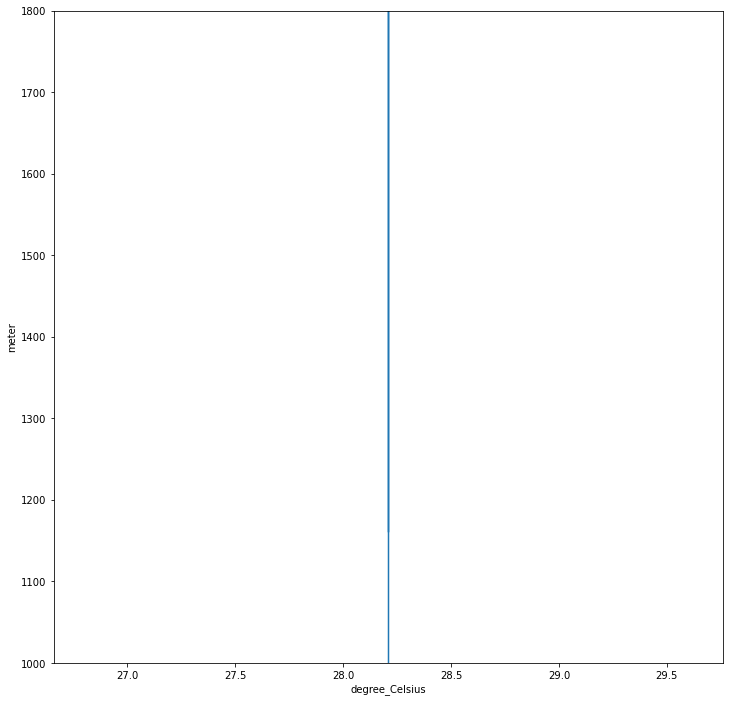

In [331]:
#This plot shows temperature vs altitude.
fig = plt.figure(1, figsize=(12,12))
plt.plot(NI_L1temp_o, NI_L1alt_o)
plt.ylim(1000,1800)

In [332]:
NI_autou, NI_autov = wind_components(NI_L1autospd, NI_L1autodir)

Text(0.5, 0, 'U-Component (m/s)')

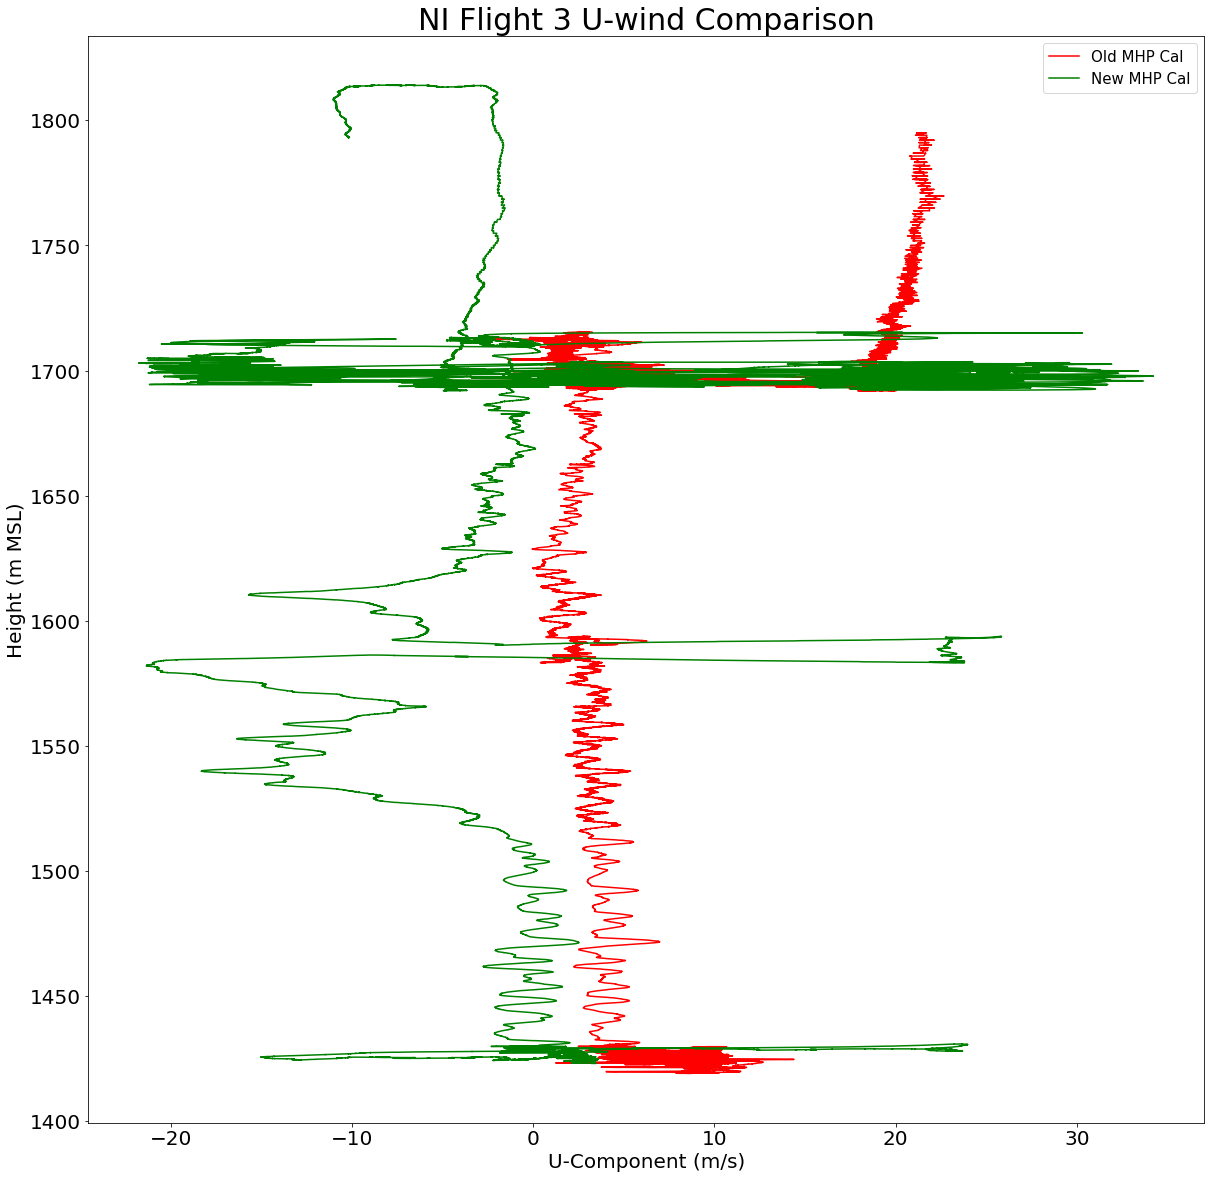

In [342]:
#This plot shows wind vs altitude, and is helpful in seeing if the data is good. 
#You may want to comment out or ignore the green line, since it's from a not-so-great calibration.
fig = plt.figure(1, figsize=(20,20))
plt.plot(NI_L2v[30000:200000], NI_L1alt_o[30000:200000], color='r', label='Old MHP Cal')
plt.plot(NI_L3u[30000:200000], NI_L3z[30000:200000], color='green', label='New MHP Cal')
#plt.plot(NI_autov, NI_L1autoalt, color='blue', label='Autopilot Science Winds')
plt.title('NI Flight 3 U-wind Comparison', size=30)
plt.legend(fontsize=15)
plt.xticks(size=20)
plt.yticks(size=20)
plt.ylabel('Height (m MSL)', size=20)
plt.xlabel('U-Component (m/s)', size=20)
#plt.ylim(1000, 1800)
#plt.savefig('NI_Flight3_Ucomparison.png')

In [334]:
print(NI_L1.variables)

{'autopilot_attitude_sample_time': <class 'netCDF4._netCDF4.Variable'>
float64 autopilot_attitude_sample_time(autopilot_attitude_dim1)
    Description: MICRO seconds since power on of aircraft.
    Units: microseconds
unlimited dimensions: 
current shape = (2718,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'autopilot_attitude_autopilot_time': <class 'netCDF4._netCDF4.Variable'>
float64 autopilot_attitude_autopilot_time(autopilot_attitude_dim1)
unlimited dimensions: 
current shape = (2718,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'autopilot_attitude_yaw': <class 'netCDF4._netCDF4.Variable'>
float64 autopilot_attitude_yaw(autopilot_attitude_dim1)
    Units: degrees
unlimited dimensions: 
current shape = (2718,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'autopilot_attitude_pitch': <class 'netCDF4._netCDF4.Variable'>
float64 autopilot_attitude_pitch(autopilot_attitude_dim1)
    Units: degrees
unlimited dimensions: 
current shape 

In [338]:
print(NI_L2v.shape)
print(NI_L3v.shape)

(243250,)
(284862,)
